# Retrieval Evaluation — đánh giá truy hồi content-based trên bộ 300 gold

Notebook riêng (độc lập) để tránh xung đột autosave với `unified_gold_validation.ipynb`. Tự nạp 300 nhãn vàng từ `verA_kappa.xlsx`, mã hóa persona bằng **SBERT-ML**, tính metric truy hồi với relevance = **Jaccard nhãn gold ≥ TAU**, so với baseline ngẫu nhiên. Xuất `retrieval_results.xlsx` + biểu đồ.

**Relevance (ground-truth proxy):** 2 persona liên quan nếu Jaccard vector nhãn gold ≥ TAU. Nhãn `fnb_street` phổ quát bị Jaccard tự loại trọng số → sức phân biệt từ nhãn hiếm chia sẻ. Đây là proxy reproducible; A/B hành vi thật là future work.


In [1]:
!pip install -q sentence-transformers scikit-learn pandas numpy matplotlib openpyxl


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\DUNG\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

GOLD_XLSX_PATH = 'verA_kappa.xlsx'
GOLD_SHEET = 'Worksheet'
OUTPUT_XLSX = 'retrieval_results.xlsx'
PLOT_PATH = 'retrieval_vs_random.png'

taxonomy = {
    'fnb_street': 'a', 'fnb_fine': 'a', 'fnb_cafe': 'a', 'fnb_healthy': 'a',
    'tour_cultural': 'a', 'tour_resort': 'a', 'tour_adventure': 'a',
    'tour_food': 'a', 'tour_festival': 'a',
}
labels = list(taxonomy.keys())
print('Labels:', labels)

Labels: ['fnb_street', 'fnb_fine', 'fnb_cafe', 'fnb_healthy', 'tour_cultural', 'tour_resort', 'tour_adventure', 'tour_food', 'tour_festival']


## 1. Tai bo gold 300 (tu verA_kappa.xlsx)

In [3]:
df_gold_raw = pd.read_excel(GOLD_XLSX_PATH, sheet_name=GOLD_SHEET)
gold_cols = [f'gold_{lb}' for lb in labels]
need = ['persona_id', 'merged_text'] + gold_cols
assert all(c in df_gold_raw.columns for c in need), f'Thieu cot. Co: {list(df_gold_raw.columns)}'

gold = df_gold_raw[need].copy()
for c in gold_cols:
    gold[c] = pd.to_numeric(gold[c], errors='coerce')
    gold.loc[~gold[c].isin([0, 1]), c] = np.nan  # persona 6592 (gold_tour_food=10) -> NaN

texts = gold['merged_text'].astype(str).tolist()
persona_ids = gold['persona_id'].astype(int).tolist()
y_gold = gold[gold_cols].values.astype(float)
print(f'N persona: {len(gold)}')
print('Gia tri khong hop le (NaN) / nhan:')
print(gold[gold_cols].isna().sum().to_string())

N persona: 300
Gia tri khong hop le (NaN) / nhan:
gold_fnb_street        0
gold_fnb_fine          0
gold_fnb_cafe          0
gold_fnb_healthy       0
gold_tour_cultural     0
gold_tour_resort       0
gold_tour_adventure    0
gold_tour_food         1
gold_tour_festival     0


## 2. Ma tran Jaccard (relevance) + cosine SBERT-ML (retrieval)

In [4]:
print('Encoding 300 persona bang SBERT-ML (paraphrase-multilingual-mpnet-base-v2)...')
sbert = SentenceTransformer('paraphrase-multilingual-mpnet-base-v2')
emb = sbert.encode(texts, batch_size=64, show_progress_bar=True, convert_to_numpy=True)
sim = cosine_similarity(emb)
np.fill_diagonal(sim, -1.0)  # loai chinh no

G = np.where(np.isnan(y_gold), 0, y_gold).astype(int)
inter = G @ G.T
rowsum = G.sum(axis=1)
union = rowsum[:, None] + rowsum[None, :] - inter
J = np.where(union > 0, inter / union, 0.0)
np.fill_diagonal(J, 0.0)
print(f'sim shape: {sim.shape} | Jaccard shape: {J.shape}')

Encoding 300 persona bang SBERT-ML (paraphrase-multilingual-mpnet-base-v2)...


Batches:   0%|          | 0/5 [00:00<?, ?it/s]

sim shape: (300, 300) | Jaccard shape: (300, 300)


## 3. Tinh P@K, Recall@K, NDCG@K, MAP, MRR + random baseline

In [5]:
TAU_LIST = [0.5, 0.6, 0.75]
K_LIST = [5, 10]

def ranking_metrics(sim, rel, k_list):
    N = sim.shape[0]
    order = np.argsort(-sim, axis=1)
    out = {}
    for k in k_list:
        prec = []; rec = []; ndcg = []
        for i in range(N):
            ri = rel[i]; nrel = int(ri.sum())
            if nrel == 0: continue
            topk = order[i, :k]
            hits = int(ri[topk].sum())
            prec.append(hits / k); rec.append(hits / nrel)
            dcg = sum(int(ri[topk[m]]) / np.log2(m + 2) for m in range(k))
            idcg = sum(1 / np.log2(m + 2) for m in range(min(nrel, k)))
            ndcg.append(dcg / idcg if idcg > 0 else 0.0)
        out[f'P@{k}'] = float(np.mean(prec)) if prec else np.nan
        out[f'Recall@{k}'] = float(np.mean(rec)) if rec else np.nan
        out[f'NDCG@{k}'] = float(np.mean(ndcg)) if ndcg else np.nan
    aps = []; rrs = []
    for i in range(N):
        ri = rel[i]; nrel = int(ri.sum())
        if nrel == 0: continue
        oi = order[i]; hits = 0; precs = []
        for r, pos in enumerate(oi, start=1):
            if ri[pos]:
                hits += 1; precs.append(hits / r)
            if hits == nrel: break
        aps.append(float(np.mean(precs)) if precs else 0.0)
        for r, pos in enumerate(oi, start=1):
            if ri[pos]: rrs.append(1.0 / r); break
    out['MAP'] = float(np.mean(aps)) if aps else np.nan
    out['MRR'] = float(np.mean(rrs)) if rrs else np.nan
    return out

retr_rows = []
for tau in TAU_LIST:
    rel = (J >= tau)
    n_with = int((rel.sum(axis=1) > 0).sum())
    m = ranking_metrics(sim, rel, K_LIST)
    m['TAU'] = tau; m['N_with_relevant'] = n_with
    retr_rows.append(m)
retr_df = pd.DataFrame(retr_rows)[['TAU', 'N_with_relevant', 'P@5', 'Recall@5', 'NDCG@5', 'P@10', 'Recall@10', 'NDCG@10', 'MAP', 'MRR']]
print('=== Retrieval metrics (cosine SBERT-ML, relevance = Jaccard(gold) >= TAU) ===')
print(retr_df.to_string(index=False))

rand_rows = []
Nn = sim.shape[0] - 1
for tau in TAU_LIST:
    rel = (J >= tau)
    nrel_per = rel.sum(axis=1)
    valid = nrel_per[nrel_per > 0]
    prev = (nrel_per / Nn)
    rand_rows.append({'TAU': tau, 'N_with_relevant': int(len(valid)),
                      'exp_P@5': float(prev.mean()) if len(valid) else np.nan,
                      'exp_P@10': float(prev.mean()) if len(valid) else np.nan})
rand_df = pd.DataFrame(rand_rows)
print('\n=== Random baseline (expected P@K = relevant prevalence) ===')
print(rand_df.to_string(index=False))

=== Retrieval metrics (cosine SBERT-ML, relevance = Jaccard(gold) >= TAU) ===
 TAU  N_with_relevant      P@5  Recall@5   NDCG@5     P@10  Recall@10  NDCG@10      MAP      MRR
0.50              300 0.708667  0.016239 0.710524 0.721000   0.033644 0.718494 0.722490 0.826742
0.60              299 0.533779  0.016645 0.541209 0.536789   0.032646 0.540831 0.544449 0.713094
0.75              291 0.270790  0.015166 0.276453 0.284192   0.032324 0.284252 0.303391 0.468183

=== Random baseline (expected P@K = relevant prevalence) ===
 TAU  N_with_relevant  exp_P@5  exp_P@10
0.50              300 0.716923  0.716923
0.60              299 0.536856  0.536856
0.75              291 0.285819  0.285819


## 4. Xuat Excel + bieu do

Da xuat retrieval_results.xlsx


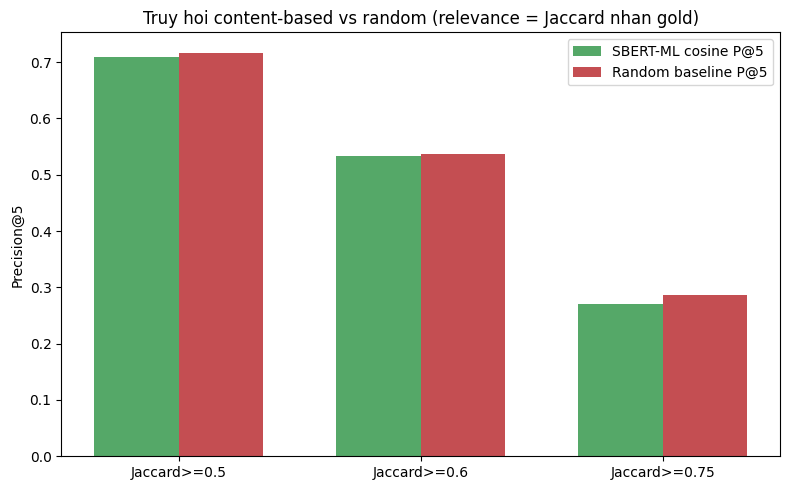

Da luu retrieval_vs_random.png


In [6]:
with pd.ExcelWriter(OUTPUT_XLSX, engine='openpyxl') as w:
    retr_df.to_excel(w, sheet_name='Retrieval_Metrics', index=False)
    rand_df.to_excel(w, sheet_name='Retrieval_RandomBaseline', index=False)
print(f'Da xuat {OUTPUT_XLSX}')

fig, ax = plt.subplots(figsize=(8, 5))
width = 0.35; xs = np.arange(len(TAU_LIST))
ax.bar(xs - width/2, retr_df['P@5'], width, label='SBERT-ML cosine P@5', color='#55A868')
ax.bar(xs + width/2, rand_df['exp_P@5'], width, label='Random baseline P@5', color='#C44E52')
ax.set_xticks(xs); ax.set_xticklabels([f'Jaccard>={t}' for t in TAU_LIST])
ax.set_ylabel('Precision@5')
ax.set_title('Truy hoi content-based vs random (relevance = Jaccard nhan gold)')
ax.legend(); plt.tight_layout(); plt.savefig(PLOT_PATH, dpi=120); plt.show()
print(f'Da luu {PLOT_PATH}')